200. Number of Islands
Solved
Medium
Topics
premium lock icon
Companies
Given an m x n 2D binary grid grid which represents a map of '1's (land) and '0's (water), return the number of islands.

An island is surrounded by water and is formed by connecting adjacent lands horizontally or vertically. You may assume all four edges of the grid are all surrounded by water.

 

Example 1:

Input: grid = [
  ["1","1","1","1","0"],
  ["1","1","0","1","0"],
  ["1","1","0","0","0"],
  ["0","0","0","0","0"]
]
Output: 1
Example 2:

Input: grid = [
  ["1","1","0","0","0"],
  ["1","1","0","0","0"],
  ["0","0","1","0","0"],
  ["0","0","0","1","1"]
]
Output: 3
 

In [ ]:
class Solution(object):

    #helper function to handle children through recursion
    def dfs(self,grid, r, c):
        #change the current 1 weve seen to 0 so we dont mistakenly visit it again
        grid[r][c] = "0"
        #lst to handle all 4 positions
        lst = [(r-1, c),(r+1, c), (r,c-1), (r, c+1)]
        for row, col in lst:
            #make sure the positions arent overboard and whatever new child we find is 1 before proceeding to do recursion
            if row>=0 and col>=0 and row<len(grid) and col<len(grid[r]) and grid[row][col] == "1":
                self.dfs(grid, row, col)

    #start here
    def numIslands(self, grid):
        """
        :type grid: List[List[str]]
        :rtype: int
        """

        island = 0 
        #iterate through the grid
        for r in range(len(grid)):
            for c in range(len(grid[r])):
                if grid[r][c] == "1":
                    #helper function to handle the children
                    self.dfs(grid, r, c)
                    island += 1
        return island





733. Flood Fill
Solved
Easy
Topics
premium lock icon
Companies
Hint
You are given an image represented by an m x n grid of integers image, where image[i][j] represents the pixel value of the image. You are also given three integers sr, sc, and color. Your task is to perform a flood fill on the image starting from the pixel image[sr][sc].

To perform a flood fill:

Begin with the starting pixel and change its color to color.
Perform the same process for each pixel that is directly adjacent (pixels that share a side with the original pixel, either horizontally or vertically) and shares the same color as the starting pixel.
Keep repeating this process by checking neighboring pixels of the updated pixels and modifying their color if it matches the original color of the starting pixel.
The process stops when there are no more adjacent pixels of the original color to update.
Return the modified image after performing the flood fill.

 

Example 1:

Input: image = [[1,1,1],[1,1,0],[1,0,1]], sr = 1, sc = 1, color = 2

Output: [[2,2,2],[2,2,0],[2,0,1]]

Explanation:



From the center of the image with position (sr, sc) = (1, 1) (i.e., the red pixel), all pixels connected by a path of the same color as the starting pixel (i.e., the blue pixels) are colored with the new color.

Note the bottom corner is not colored 2, because it is not horizontally or vertically connected to the starting pixel.

Example 2:

Input: image = [[0,0,0],[0,0,0]], sr = 0, sc = 0, color = 0

Output: [[0,0,0],[0,0,0]]

Explanation:

The starting pixel is already colored with 0, which is the same as the target color. Therefore, no changes are made to the image.

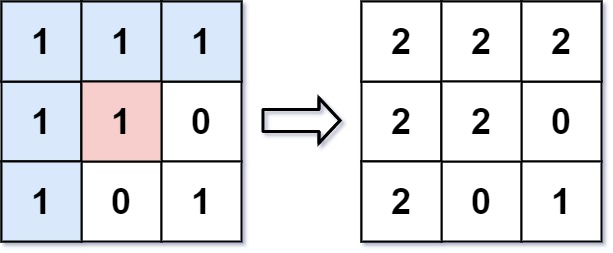

In [ ]:
class Solution(object):
    def floodFill(self, image, sr, sc, color):
        """
        :type image: List[List[int]]
        :type sr: int
        :type sc: int
        :type color: int
        :rtype: List[List[int]]
        """
        starting_point = image[sr][sc]              #get starting point
        
        self.dfs(image, sr, sc, color, starting_point)  #use dfs to handle both change of colour and subsequest operations for neighbours

        return image                                            

    def dfs(self, image, sr, sc, color, starting_point):
    #if rows and cols go overboard, return | if current pixel = red already, means we've visited it before then return | if curr pixel is not same as starting point ie 1 then return

        if sr < 0 or sr > len(image)-1 or sc < 0 or sc > len(image[0])-1 or image[sr][sc] == color or image[sr][sc] != starting_point:
            return
        
        #change the color of the current pixel we are on
        image[sr][sc] = color
        self.dfs(image, sr+1, sc, color,starting_point)            #handle down
        self.dfs(image, sr-1, sc, color,starting_point)            #handle up
        self.dfs(image, sr, sc+1, color, starting_point)           #handle right
        self.dfs(image, sr, sc-1, color, starting_point)           #handle left